# MRIxFields2026 — Evaluation

Evaluate predicted volumes against ground-truth scans for **Task 1** (this Tutorial's example: 0.1T → 7T, T1W).

1. **Setup** — paths to predictions and targets
2. **Single pair** — load one pred-target pair, inspect shapes/intensity
3. **Voxel metrics** — nRMSE, SSIM, LPIPS  *(required by all 3 tasks)*
4. **Visualization** — prediction / target / error map
5. **Batch evaluation** — aggregate across the validation set, dump CSV
6. **Segmentation metrics** — Dice and volume consistency on DGM structures *(Task 1 / Task 2 only — see note below)*
7. **Full submission flow** — segment, build, zip, upload

> **Task 3** is evaluated on **voxel-level metrics only** (nRMSE / SSIM / LPIPS) — **no SynthSeg, no Dice/Volume, no `seg/` in the submission zip**. See [Evaluation/README.md](../Evaluation/README.md) and main [README §5](../README.md#5-evaluate-your-results).

Prerequisite: predictions from notebook 02 (saved in `tmp/inference/`) or from [`Baseline/scripts/inference.py`](../Baseline/scripts/inference.py).

In [1]:
import sys, os
from pathlib import Path

# Resolve paths relative to this notebook's location.
# nbconvert may run from repo root, so we check both possibilities.
if Path('tmp/inference').exists():
    _tutorial = Path('.')
elif Path('Tutorial/tmp/inference').exists():
    _tutorial = Path('Tutorial')
else:
    _tutorial = Path('.')

sys.path.insert(0, str((_tutorial / '..' / 'Baseline').resolve()))
sys.path.insert(0, str((_tutorial / '..' / 'Evaluation').resolve()))

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from mrixfields.env import load_env
from mrixfields.data.utils import load_nifti
from evaluate import (
    compute_nrmse, compute_ssim, compute_lpips,
    evaluate_pair, match_by_subject_prefix,
)

load_env()
DATA_DIR = Path(os.environ['DATA_DIR'])
INFERENCE_DIR = (_tutorial / 'tmp' / 'inference').resolve()

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print(f'Predictions: {INFERENCE_DIR.relative_to(INFERENCE_DIR.parent.parent)}')
print(f'Data root:   .../{DATA_DIR.name}')

Predictions: tmp/inference
Data root:   .../release_20260414


## 1. Locate a prediction–target pair

Notebook 02 saves predictions to `tmp/inference/` with target-field filenames (`P_T1W_7T_{ID}.nii.gz`, no `_pred` suffix). Targets are the 7T scans of the same subjects in `Training_prospective`. We match by subject ID prefix (the trailing 4-digit ID, e.g. `0007`).

> Production [`Baseline/scripts/inference.py`](../Baseline/scripts/inference.py) preserves the *source* filename (`P_T1W_0.1T_{ID}.nii.gz`); [`Submission/build_submission/build_submission.py`](../Submission/build_submission/build_submission.py) renames to the target field at packing time. `match_by_subject_prefix` matches on the trailing ID regardless of which convention you use.

In [2]:
target_dir = DATA_DIR / 'Training_prospective' / 'T1W' / '7T'

pred_files = sorted(INFERENCE_DIR.rglob('*.nii.gz'))
if not pred_files:
    print('No predictions found — run notebook 02 first.')
else:
    print(f'Predictions: {len(pred_files)} files in {INFERENCE_DIR.relative_to(INFERENCE_DIR.parent.parent)}/')
    for p in pred_files:
        print(f'  {p.name}')
    print(f'\nTarget dir:  .../{target_dir.relative_to(DATA_DIR)}/')

Predictions: 1 files in tmp/inference/
  P_T1W_7T_0007.nii.gz

Target dir:  .../Training_prospective/T1W/7T/


## 2. Voxel-level metrics on a single pair

These three metrics apply to **all 3 tasks**:

- **nRMSE** — `||pred − target||₂ / ||target||₂`. Lower is better.
- **SSIM** — slice-wise structural similarity, averaged. Range [0, 1], higher is better.
- **LPIPS** — perceptual distance with an AlexNet backbone. Lower is better.

`evaluate_pair` assumes both `pred` and `target` are in [0, 1]: predictions come out of inference as `[−1,1]→*0.5+0.5`, and target volumes are pre-normalized.

In [3]:
# Pick subject 0007 (the demo prediction from notebook 02)
subject_id = '0007'
pred_path = next((p for p in pred_files if subject_id in p.name), None)
tgt_path  = target_dir / f'P_T1W_7T_{subject_id}.nii.gz'
assert pred_path and tgt_path.exists(), f'Subject {subject_id} not found in pred or target'
print(f'Pred:   {pred_path.name}')
print(f'Target: {tgt_path.name}')

result = evaluate_pair(pred_path, tgt_path, metrics=['nrmse', 'ssim', 'lpips'])
for k, v in result.items():
    print(f'  {k:>6s}: {v:.4f}')

Pred:   P_T1W_7T_0007.nii.gz
Target: P_T1W_7T_0007.nii.gz


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


   nrmse: 0.4917
    ssim: 0.8936
   lpips: 0.0809


## 3. Visualize prediction vs. ground truth

Three axial slices (mid-1/4, mid, mid+1/4) showing prediction, target, and the absolute error map.

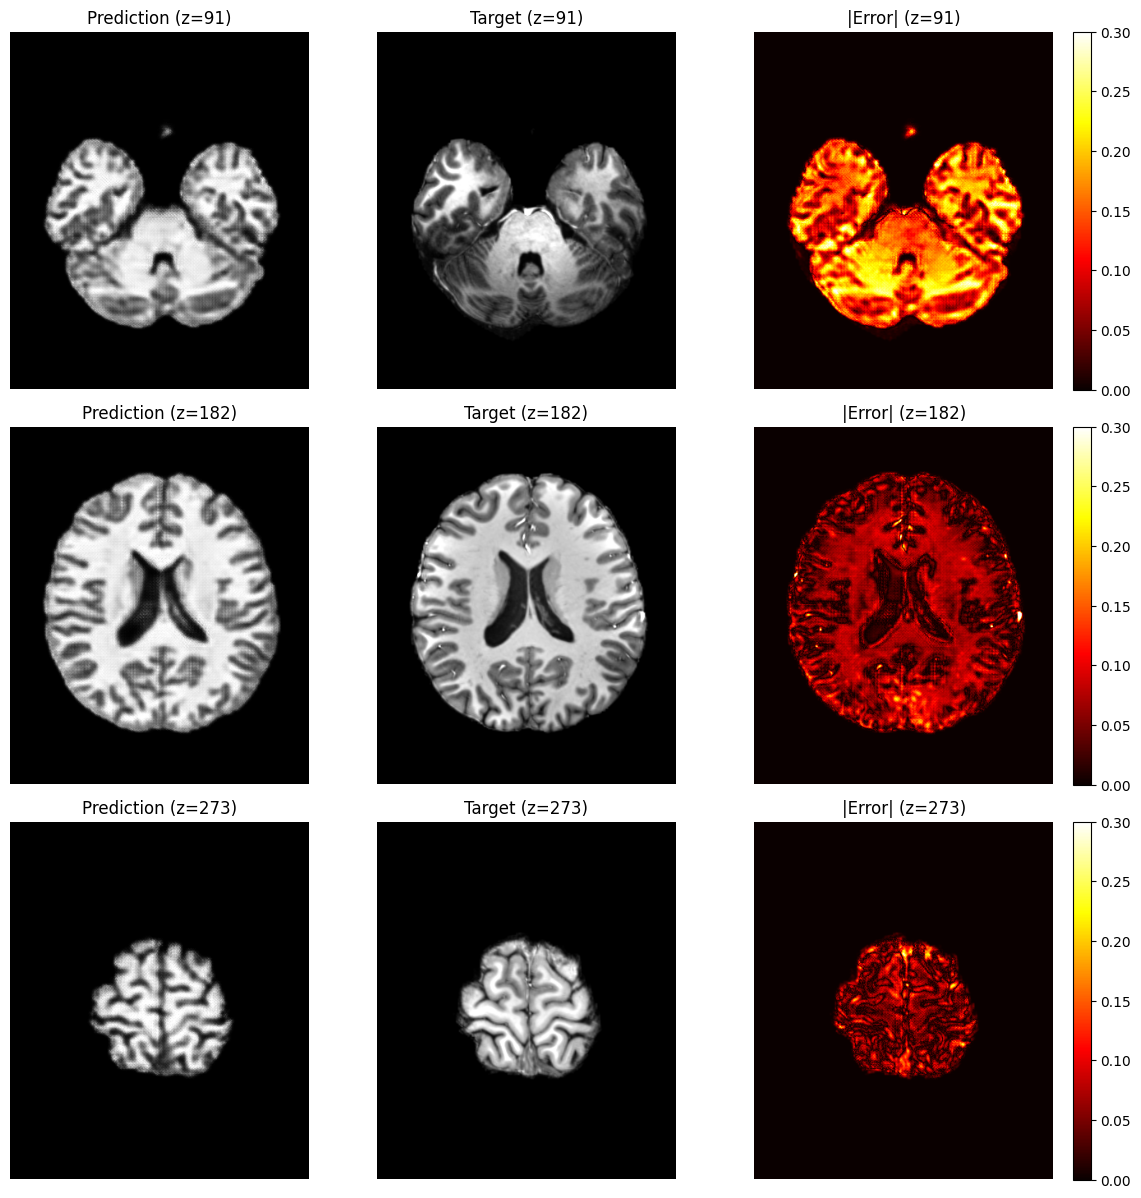

In [4]:
pred, _ = load_nifti(pred_path)
tgt, _  = load_nifti(tgt_path)

# Clip pred to [0, 1] to guard against any stray values from the model.
tgt_n = tgt.astype(np.float32)
pred_n = np.clip(pred, 0, 1).astype(np.float32)

Z = pred.shape[2]
slice_idx = [Z // 4, Z // 2, 3 * Z // 4]
# vmax = 99.5th percentile per slice: suppresses the top 0.5% bright outliers so mid-tone contrast isn't washed out.
fig, axes = plt.subplots(len(slice_idx), 3, figsize=(12, 4 * len(slice_idx)))
for row, z in enumerate(slice_idx):
    p, t = pred_n[:, :, z].T, tgt_n[:, :, z].T
    err = np.abs(p - t)
    axes[row, 0].imshow(p, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(p, 99.5))
    axes[row, 0].set_title(f'Prediction (z={z})')
    axes[row, 1].imshow(t, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(t, 99.5))
    axes[row, 1].set_title(f'Target (z={z})')
    im = axes[row, 2].imshow(err, cmap='hot', origin='lower', vmin=0, vmax=0.3)
    axes[row, 2].set_title(f'|Error| (z={z})')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)
    for ax in axes[row]: ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Batch evaluation

`match_by_subject_prefix` matches predictions to targets by the trailing subject ID; we then call `evaluate_pair` per pair and dump a per-subject CSV.

In [5]:
import csv

csv_path = INFERENCE_DIR / 'eval_results.csv'
metrics = ['nrmse', 'ssim', 'lpips']

pairs = match_by_subject_prefix(INFERENCE_DIR, target_dir)
all_results = []
for pred_path, tgt_path in pairs:
    # Subject ID is the trailing ID parsed by evaluate._extract_subject_id
    subject = pred_path.name.replace('.nii.gz', '').split('_')[-1]
    result = evaluate_pair(pred_path, tgt_path, metrics=metrics)
    result['subject'] = subject
    all_results.append(result)
    vals = ' | '.join(f'{k}: {v:.4f}' for k, v in result.items() if k != 'subject')
    print(f'  {subject}: {vals}')

if all_results:
    metric_cols = [k for k in all_results[0] if k != 'subject']
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['subject'] + metric_cols)
        w.writeheader()
        w.writerows(all_results)
    means = {k: np.mean([r[k] for r in all_results]) for k in metric_cols}
    print(f'\nMean:  ' + ' | '.join(f'{k}: {v:.4f}' for k, v in means.items()))
    print(f'Per-subject CSV: {csv_path.relative_to(csv_path.parent.parent.parent)}')
else:
    print('No matching pairs found.')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Loading model from: /home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


  0007: nrmse: 0.4917 | ssim: 0.8936 | lpips: 0.0809

Mean:  nrmse: 0.4917 | ssim: 0.8936 | lpips: 0.0809
Per-subject CSV: tmp/inference/eval_results.csv


## 5. SynthSeg Segmentation *(Task 1 / Task 2 only)*

Run [SynthSeg 2.0](https://github.com/BBillot/SynthSeg) on the prediction and ground-truth volumes to produce brain segmentation maps. These are used to compute **Dice** overlap and **volume consistency** on 14 deep gray matter (DGM) structures.

We write segmentations to two sibling directories (`tmp/seg/pred/` and `tmp/seg/target/`) so they can be passed cleanly to `Evaluation/evaluate.py` via `--pred_seg_dir` / `--target_seg_dir`.

> **Skip this section for Task 3** — Task 3 ranking uses only the 3 voxel metrics above.

In [6]:
from segment import run_synthseg, _get_synthseg_dir

synthseg_dir = _get_synthseg_dir()

seg_root = (_tutorial / 'tmp' / 'seg').resolve()
pred_seg_dir = seg_root / 'pred'
tgt_seg_dir  = seg_root / 'target'
pred_seg_dir.mkdir(parents=True, exist_ok=True)
tgt_seg_dir.mkdir(parents=True, exist_ok=True)

# segment.py output suffix is '_seg' (no _pred suffix)
pred_seg_path = pred_seg_dir / pred_path.name.replace('.nii.gz', '_seg.nii.gz')
tgt_seg_path  = tgt_seg_dir  / tgt_path.name.replace('.nii.gz', '_seg.nii.gz')

if not pred_seg_path.exists():
    print(f'Segmenting prediction: {pred_path.name}')
    run_synthseg(pred_path, pred_seg_path, synthseg_dir)
else:
    print(f'Prediction seg exists: {pred_seg_path.name}')

if not tgt_seg_path.exists():
    print(f'Segmenting target: {tgt_path.name}')
    run_synthseg(tgt_path, tgt_seg_path, synthseg_dir)
else:
    print(f'Target seg exists: {tgt_seg_path.name}')

print(f'\nSegmentations saved to:')
print(f'  pred:   {pred_seg_dir.relative_to(seg_root.parent.parent)}/')
print(f'  target: {tgt_seg_dir.relative_to(seg_root.parent.parent)}/')

Segmenting prediction: P_T1W_7T_0007.nii.gz


2026-05-11 20:22:20.710346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-11 20:22:20.710388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-11 20:22:20.711776: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-11 20:22:20.718500: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-05-11 20:22:21.617233: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2026-05-11 20:22:22.798176: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-11 20:22:22.799406: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-11 20:22:22.802176: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Instructions for updating:
Use fn_output_signature instead


...

predicting 1/1


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 858ms/step


2026-05-11 20:23:00.142101: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1089994752 exceeds 10% of free system memory.



segmentation  saved in:    /home/jh/workspace/fdu/MRIxFields2026-Dev/Tutorial/tmp/seg/target/P_T1W_7T_0007_seg.nii.gz

If you use this tool in a publication, please cite:
SynthSeg: domain randomisation for segmentation of brain MRI scans of any contrast and resolution
B. Billot, D.N. Greve, O. Puonti, A. Thielscher, K. Van Leemput, B. Fischl, A.V. Dalca, J.E. Iglesias

Segmentations saved to:
  pred:   tmp/seg/pred/
  target: tmp/seg/target/


## 6. Visualize segmentation

Overlay SynthSeg labels on prediction and ground truth at three axial slices. SynthSeg 2.0 segments the brain into 32 structures (cortex, white matter, deep gray matter, ventricles, etc.). The 14 DGM structures used for Dice/Volume metrics are highlighted with thicker boundaries.

Seg shape: (182, 218, 182) (1mm isotropic)
Total structures: 32


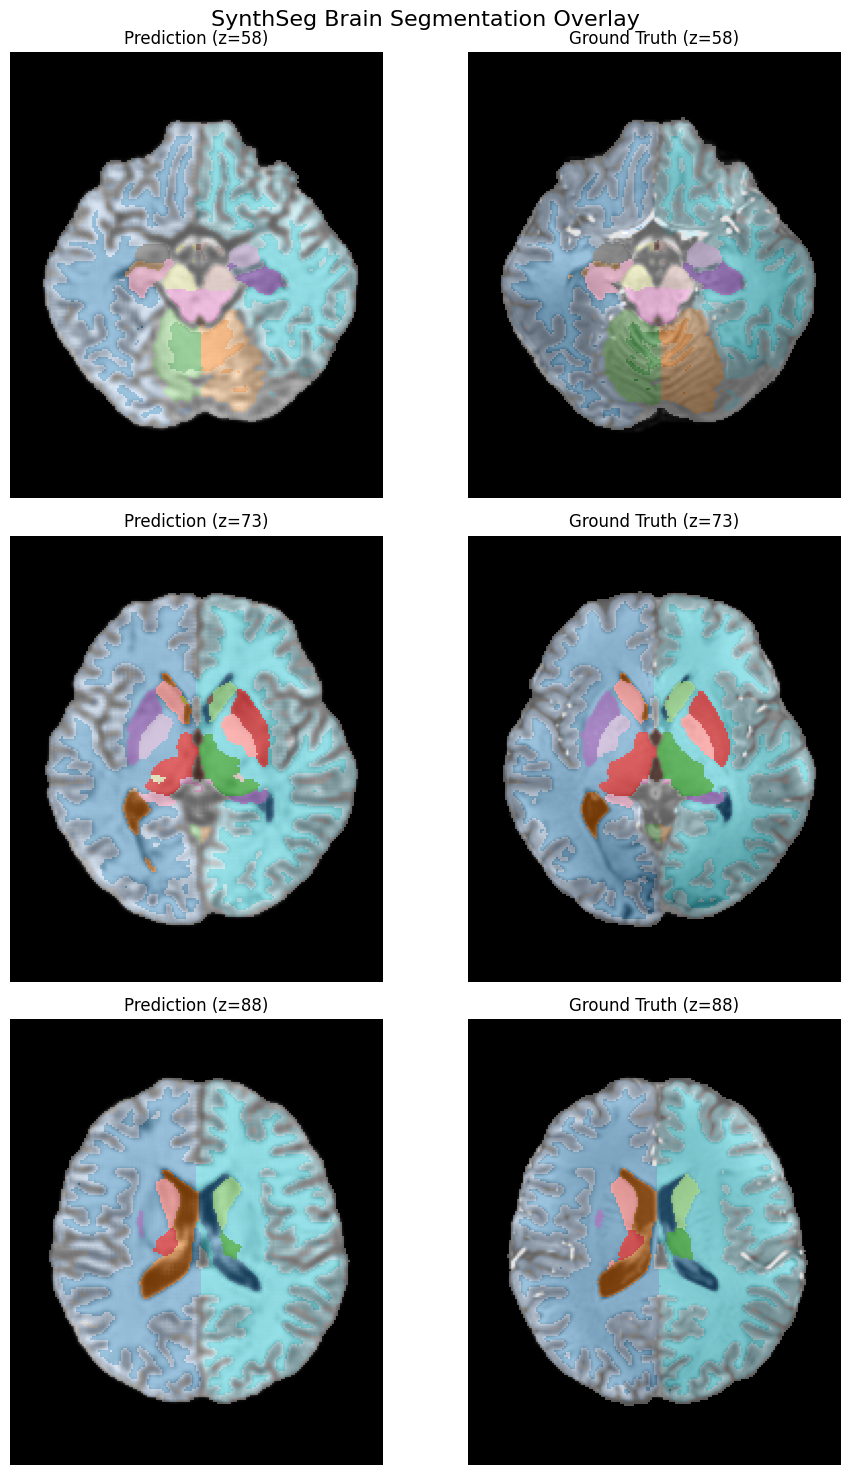

In [7]:
from evaluate import DGM_LABELS
from scipy.ndimage import zoom as ndi_zoom
import matplotlib.colors as mcolors

# Load segmentation maps (1mm isotropic, resampled by SynthSeg)
pred_seg_vol = nib.as_closest_canonical(nib.load(pred_seg_path)).get_fdata().astype(np.int32)
tgt_seg_vol  = nib.as_closest_canonical(nib.load(tgt_seg_path)).get_fdata().astype(np.int32)

all_labels = sorted(set(np.unique(pred_seg_vol)) | set(np.unique(tgt_seg_vol)))
all_labels = [l for l in all_labels if l != 0]
print(f'Seg shape: {pred_seg_vol.shape} (1mm isotropic)')
print(f'Total structures: {len(all_labels)}')

dgm_ids = set(DGM_LABELS.values())

# Downsample pred/tgt volumes to match seg resolution for overlay
pred_vol, _ = load_nifti(pred_path)
tgt_vol, _  = load_nifti(tgt_path)

scale = np.array(pred_seg_vol.shape) / np.array(pred_vol.shape)
pred_ds = ndi_zoom(pred_vol, scale, order=1)
tgt_ds  = ndi_zoom(tgt_vol, scale, order=1)

# Build a consistent colormap: map each label to a unique color
cmap_base = plt.colormaps.get_cmap('tab20').resampled(20)
label_colors = {lbl: cmap_base(i % 20) for i, lbl in enumerate(all_labels)}

# Pick slices where DGM is visible (center of DGM range)
dgm_per_slice = [np.isin(pred_seg_vol[:, :, z], list(dgm_ids)).sum() for z in range(pred_seg_vol.shape[2])]
best_z = int(np.argmax(dgm_per_slice))
Z = pred_seg_vol.shape[2]
slice_idx = [max(0, min(z, Z - 1)) for z in [best_z - 15, best_z, best_z + 15]]

fig, axes = plt.subplots(len(slice_idx), 2, figsize=(10, 5 * len(slice_idx)))
for row, z in enumerate(slice_idx):
    for col, (vol, seg, title) in enumerate([
        (pred_ds, pred_seg_vol, 'Prediction'),
        (tgt_ds,  tgt_seg_vol,  'Ground Truth'),
    ]):
        ax = axes[row, col]
        ax.imshow(vol[:, :, z].T, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(vol[:, :, z], 99.5))
        seg_slice = seg[:, :, z].T
        rgba = np.zeros((*seg_slice.shape, 4))
        for lbl in all_labels:
            mask = seg_slice == lbl
            if mask.any():
                c = label_colors[lbl]
                rgba[mask] = [c[0], c[1], c[2], 0.7 if lbl in dgm_ids else 0.45]
        ax.imshow(rgba, origin='lower', interpolation='nearest')
        ax.set_title(f'{title} (z={z})', fontsize=12)
        ax.axis('off')

fig.suptitle('SynthSeg Brain Segmentation Overlay', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Segmentation metrics — Dice & Volume Consistency *(Task 1 / Task 2 only)*

- **Dice coefficient**: spatial overlap per DGM structure. Range [0, 1], higher is better.
- **Volume consistency**: `1 − |V_pred − V_target| / V_target` per structure. Higher is better.

Both are computed over 14 bilateral DGM structures (7 pairs).

Structure               Dice    Volume
--------------------------------------
L_Thalamus            0.8514    0.8035
R_Thalamus            0.8918    0.8742
L_Caudate             0.8979    0.9085
R_Caudate             0.8974    0.8921
L_Putamen             0.8782    0.8359
R_Putamen             0.9045    0.9104
L_Pallidum            0.8556    0.7879
R_Pallidum            0.8736    0.8217
L_Hippocampus         0.8257    0.8714
R_Hippocampus         0.8377    0.8380
L_Amygdala            0.8135    0.7273
R_Amygdala            0.7473    0.6180
L_Accumbens           0.8230    0.8609
R_Accumbens           0.8240    0.9985
--------------------------------------
Mean                  0.8515    0.8392


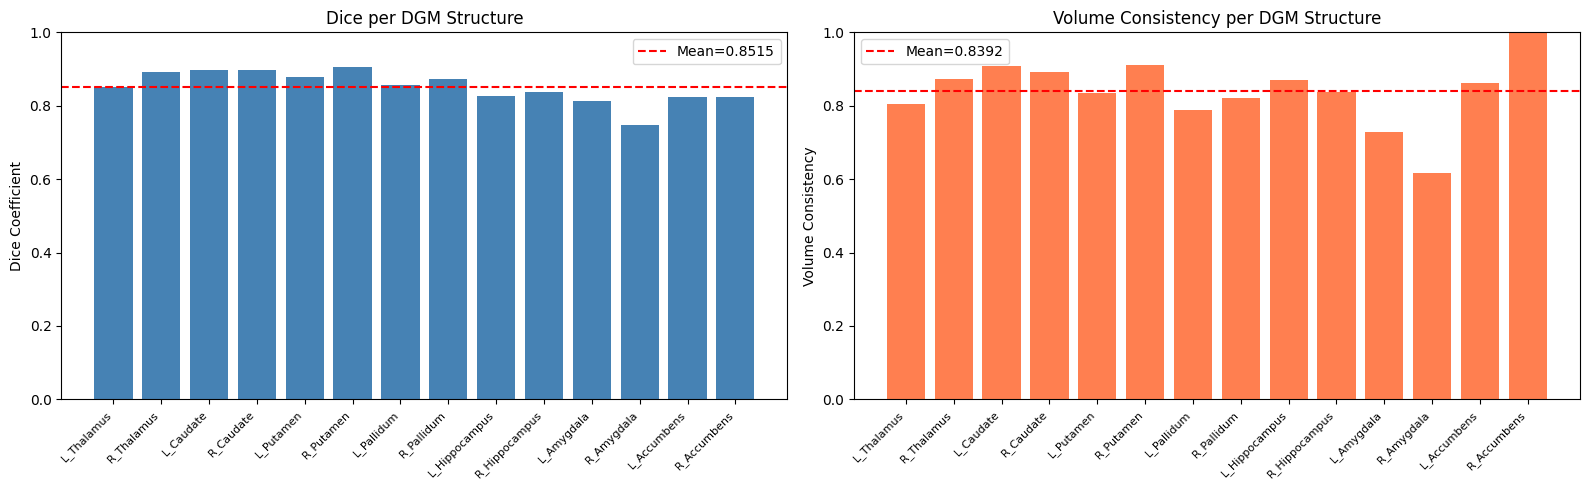

In [8]:
from evaluate import compute_dice, compute_volume_consistency, DGM_LABELS

dice_scores = compute_dice(pred_seg_vol, tgt_seg_vol, DGM_LABELS)

# Voxel volume from SynthSeg output (resampled to 1mm isotropic)
voxel_size = nib.load(tgt_seg_path).header.get_zooms()[:3]
voxel_vol = float(np.prod(voxel_size))
vol_scores = compute_volume_consistency(pred_seg_vol, tgt_seg_vol, voxel_vol, DGM_LABELS)

print(f'{"Structure":<20s}  {"Dice":>6s}  {"Volume":>8s}')
print('-' * 38)
for name in DGM_LABELS:
    print(f'{name:<20s}  {dice_scores[name]:6.4f}  {vol_scores[name]:8.4f}')
print('-' * 38)
mean_dice = float(np.mean(list(dice_scores.values())))
mean_vol  = float(np.mean(list(vol_scores.values())))
print(f'{"Mean":<20s}  {mean_dice:6.4f}  {mean_vol:8.4f}')

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
names = list(DGM_LABELS.keys())
x = np.arange(len(names))

ax1.bar(x, [dice_scores[n] for n in names], color='steelblue')
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Dice Coefficient'); ax1.set_ylim(0, 1)
ax1.axhline(mean_dice, color='red', linestyle='--', label=f'Mean={mean_dice:.4f}'); ax1.legend()
ax1.set_title('Dice per DGM Structure')

ax2.bar(x, [vol_scores[n] for n in names], color='coral')
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Volume Consistency'); ax2.set_ylim(0, 1)
ax2.axhline(mean_vol, color='red', linestyle='--', label=f'Mean={mean_vol:.4f}'); ax2.legend()
ax2.set_title('Volume Consistency per DGM Structure')

plt.tight_layout(); plt.show()

## 8. From single pair to full submission

The full local pipeline mirrors what the Synapse evaluator runs:

### Task 1 / Task 2 — 5 metrics

```bash
# (1) Inference — produces $INFERENCE_DIR/{...}.nii.gz preserving source filename
python Baseline/scripts/inference.py \
    --config Baseline/configs/task1/cut/0.1T_to_7T_T1W.yaml \
    --checkpoint $OUTPUT_DIR/.../weights/checkpoint_epoch050.pth \
    --input_dir $DATA_DIR/Validating_prospective/T1W/0.1T/

# (2) SynthSeg on predictions (Task 1/2 only)
python Baseline/scripts/segment_predictions.py --tasks task1

# (3) Build submission tree — renames source field tag to target,
#     z-clips volumes to (364, 436, 30) using Z_CLIP_RANGE=(150, 180)
#     (Baseline/mrixfields/zclip_constants.py)
python Submission/build_submission/build_submission.py

# (4) Zip per task and upload to Synapse
cd $SUBMISSION_DIR/task1
zip -r ~/task1.zip T1W T2W T2FLAIR
# Upload ~/task1.zip to Synapse syn72060672

# (5) [Optional] Local evaluation — full 5-metric scoring on validation
python Evaluation/evaluate.py \
    --pred_dir   $INFERENCE_DIR/ \
    --target_dir $DATA_DIR/Validating_prospective/T1W/7T/ \
    --pred_seg_dir   $PREDICTIONS_SEG_DIR/ \
    --target_seg_dir $DATA_DIR/.../7T_seg/ \
    --metrics nrmse ssim lpips dice volume \
    --output_csv eval_task1.csv
```

### Task 3 — 3 metrics, no segmentation

```bash
# Inference adds --target_field for StarGAN v2 domain selection
python Baseline/scripts/inference.py \
    --config Baseline/configs/task3/stargan/any_to_any_all_modalities.yaml \
    --checkpoint $OUTPUT_DIR/.../weights/checkpoint_500000.pth \
    --input_dir $DATA_DIR/Validating_prospective/T1W/0.1T/ \
    --target_field 7T

# NO segment_predictions.py step for Task 3.
# build_submission.py automatically skips seg/ for Task 3 (NEEDS_SEG['task3'] = False).
python Submission/build_submission/build_submission.py
cd $SUBMISSION_DIR/task3 && zip -r ~/task3.zip T1W T2W T2FLAIR

# Local evaluation — 3 voxel metrics only
python Evaluation/evaluate.py \
    --pred_dir   $INFERENCE_DIR/ \
    --target_dir $DATA_DIR/Validating_prospective/T1W/7T/ \
    --metrics nrmse ssim lpips \
    --output_csv eval_task3.csv
```

### Ranking

Per-metric rank summed across the applicable metrics — **5 metrics for Task 1/2**, **3 metrics for Task 3**. Lowest total wins. See main [README §5](../README.md#5-evaluate-your-results).